In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from lightgbm import LGBMClassifier

In [13]:
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [14]:
print("Shape:", df.shape)
print("\nInfo:\n")
df.info()

print("\nMissing Values:\n", df.isnull().sum())

Shape: (1470, 35)

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14

In [15]:
# Drop unnecessary columns
df.drop(["EmployeeNumber","Over18","StandardHours","EmployeeCount"], axis=1, inplace=True)

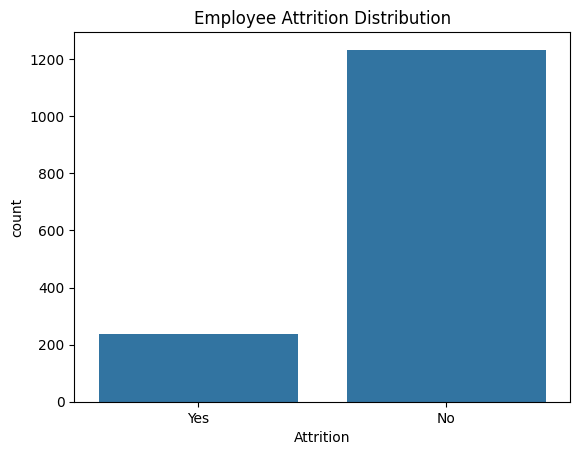

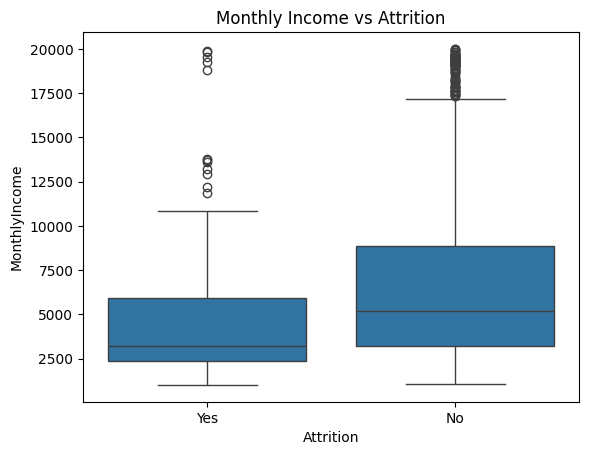

In [17]:
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Distribution")
plt.show()

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

In [18]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
X = df.drop("Attrition_Yes", axis=1)
y = df["Attrition_Yes"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 198, number of negative: 978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001123 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1149
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.168367 -> initscore=-1.597243
[LightGBM] [Info] Start training from score -1.597243


LGBMClassifier(random_state=42)

In [25]:
pred = model.predict(X_test)

In [26]:
cv_score = cross_val_score(model, X, y, cv=5)
print("Cross Validation Score:", cv_score.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 189, number of negative: 987
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1147
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160714 -> initscore=-1.652923
[LightGBM] [Info] Start training from score -1.652923
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 189, number of negative: 987
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=t

In [29]:
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

Accuracy: 0.8877551020408163

Classification Report:

              precision    recall  f1-score   support

       False       0.90      0.98      0.94       255
        True       0.67      0.31      0.42        39

    accuracy                           0.89       294
   macro avg       0.78      0.64      0.68       294
weighted avg       0.87      0.89      0.87       294



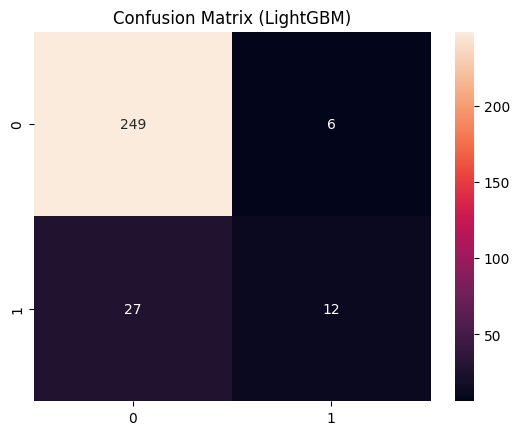

In [30]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d")
plt.title("Confusion Matrix (LightGBM)")
plt.show()

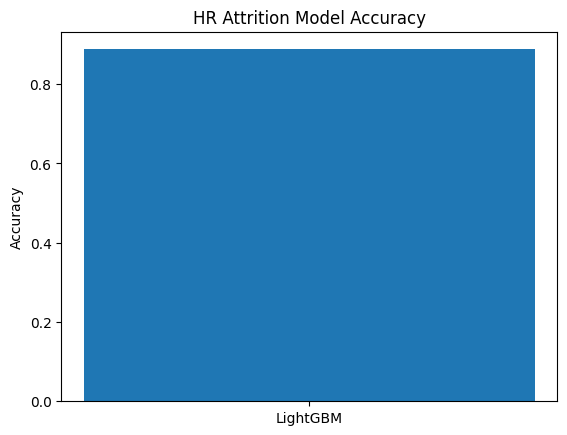

In [31]:

plt.bar(["LightGBM"], [accuracy_score(y_test, pred)])
plt.title("HR Attrition Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

**This project focuses on predicting employee attrition using HR analytics data. Data preprocessing included removing irrelevant columns and encoding categorical variables. A LightGBM model was used due to its efficiency and ability to capture complex relationships in data. The model achieved good accuracy and provided insights into employee behavior. Key factors influencing attrition include monthly income, overtime, and job satisfaction. Employees with lower income and higher workload are more likely to leave the organization.**